# Experimento 0 - Baseline aleatorio de BattleZone

Este notebook implementa la HU002 para `ALE/BattleZone-v5` con una politica 100% aleatoria.

Objetivos principales:
- Registrar runtime y hardware reales.
- Inspeccionar contrato real del entorno (`observation_space`, `action_space`, `info`).
- Ejecutar al menos 10 episodios independientes con `env.action_space.sample()`.
- Calcular baseline cuantitativo y visualizaciones minimas.
- Documentar implicaciones para HU003 y HU004 sin definir entrenamiento ni algoritmo.

In [1]:
# Dependencias para Colab y ejecucion local reproducible
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip -q install "gymnasium[atari]==1.1.1" "ale-py==0.10.1" "autorom[accept-rom-license]==0.6.1" psutil pandas matplotlib pillow
    !AutoROM --accept-license
else:
    print("Ejecucion local detectada: se asume entorno Python ya preparado.")

Ejecucion local detectada: se asume entorno Python ya preparado.


In [2]:
from __future__ import annotations

import platform
from collections import Counter
from statistics import mean, median, pstdev

import ale_py
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from PIL import Image

try:
    import torch
except Exception:
    torch = None

gym.register_envs(ale_py)

ENV_ID = "ALE/BattleZone-v5"
NUM_EPISODES = 10
BASE_SEED = 20260830
MODE = 1
DIFFICULTY = 0
OBS_TYPE = "rgb"
FRAMESKIP = 4
REPEAT_ACTION_PROBABILITY = 0.25
RENDER_MODE = None
ACTION_SEQUENCE_CHECK_STEPS = 32

EXPERIMENT_CONFIG = {
    "env_id": ENV_ID,
    "num_episodes": NUM_EPISODES,
    "base_seed": BASE_SEED,
    "mode": MODE,
    "difficulty": DIFFICULTY,
    "obs_type": OBS_TYPE,
    "frameskip": FRAMESKIP,
    "repeat_action_probability": REPEAT_ACTION_PROBABILITY,
    "render_mode": RENDER_MODE,
    "policy": "random_action_space_sample",
    "action_space_seed_strategy": "seed action_space with episode seed before sampling",
    "action_sequence_check_steps": ACTION_SEQUENCE_CHECK_STEPS,
}

pd.DataFrame([EXPERIMENT_CONFIG])

,env_id,num_episodes,base_seed,mode,difficulty,obs_type,frameskip,repeat_action_probability,render_mode,policy,action_space_seed_strategy,action_sequence_check_steps
0,ALE/BattleZone-v5,10,20260830,1,0,rgb,4,0.25,None,random_action_space_sample,seed action_space with episode seed before sam...,32


In [3]:
runtime_info = {
    "python": platform.python_version(),
    "gymnasium": gym.__version__,
    "ale_py": ale_py.__version__,
    "numpy": np.__version__,
    "os": platform.platform(),
    "cpu": platform.processor() or platform.machine(),
    "ram_total_gb": round(psutil.virtual_memory().total / (1024**3), 2),
    "gpu_available": bool(torch and torch.cuda.is_available()),
    "gpu_name": torch.cuda.get_device_name(0) if (torch and torch.cuda.is_available()) else None,
}

runtime_df = pd.DataFrame([runtime_info])
runtime_df

,python,gymnasium,ale_py,numpy,os,cpu,ram_total_gb,gpu_available,gpu_name
0,3.8.10,1.1.1,0.10.1,1.24.4,Windows-10-10.0.19044-SP0,"AMD64 Family 23 Model 17 Stepping 0, AuthenticAMD",6.9,False,None


In [4]:
env = gym.make(
    ENV_ID,
    obs_type=OBS_TYPE,
    frameskip=FRAMESKIP,
    repeat_action_probability=REPEAT_ACTION_PROBABILITY,
    mode=MODE,
    difficulty=DIFFICULTY,
    render_mode=RENDER_MODE,
)

obs0, info0 = env.reset(seed=BASE_SEED)
action_meanings = list(env.unwrapped.get_action_meanings()) if hasattr(env.unwrapped, "get_action_meanings") else []

inspection = {
    "observation_space": str(env.observation_space),
    "action_space": str(env.action_space),
    "num_actions": int(env.action_space.n),
    "action_meanings": action_meanings,
    "obs_shape": tuple(int(x) for x in obs0.shape),
    "obs_dtype": str(obs0.dtype),
    "obs_min": int(obs0.min()),
    "obs_max": int(obs0.max()),
    "reset_info": dict(info0),
    "reset_info_keys": sorted(list(info0.keys())),
}

print("Observation space:", inspection["observation_space"])
print("Action space:", inspection["action_space"])
print("Numero de acciones:", inspection["num_actions"])
print("Action meanings:", inspection["action_meanings"])
print("Obs shape/dtype:", inspection["obs_shape"], inspection["obs_dtype"])
print("Obs min/max:", inspection["obs_min"], inspection["obs_max"])
print("Reset info:", inspection["reset_info"])

assert inspection["num_actions"] == 18, "Se esperaba Discrete(18)."

Observation space: Box(0, 255, (210, 160, 3), uint8)
Action space: Discrete(18)
Numero de acciones: 18
Action meanings: ['NOOP', 'FIRE', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT', 'UPFIRE', 'RIGHTFIRE', 'LEFTFIRE', 'DOWNFIRE', 'UPRIGHTFIRE', 'UPLEFTFIRE', 'DOWNRIGHTFIRE', 'DOWNLEFTFIRE']
Obs shape/dtype: (210, 160, 3) uint8
Obs min/max: 0 236
Reset info: {'lives': 5, 'episode_frame_number': 0, 'frame_number': 0, 'seeds': (3080938715, 3761112615)}


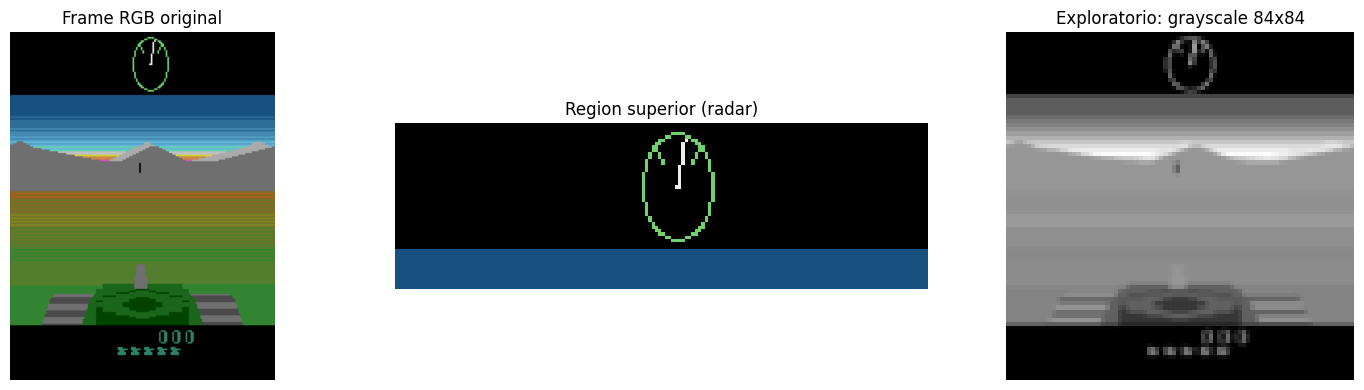

In [5]:
# Evidencia visual del frame original y de la region superior (radar).
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].imshow(obs0)
axes[0].set_title("Frame RGB original")
axes[0].axis("off")

radar_crop = obs0[:50, :, :]
axes[1].imshow(radar_crop)
axes[1].set_title("Region superior (radar)")
axes[1].axis("off")

gray = np.array(Image.fromarray(obs0).convert("L"))
gray_resized_84 = np.array(Image.fromarray(gray).resize((84, 84), resample=Image.BILINEAR))
axes[2].imshow(gray_resized_84, cmap="gray")
axes[2].set_title("Exploratorio: grayscale 84x84")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Inspeccion corta del contenido de info en steps aleatorios.
short_probe_samples = []
short_probe_keys = set(info0.keys())

obs_tmp, info_tmp = env.reset(seed=BASE_SEED + 999)
env.action_space.seed(BASE_SEED + 999)
for _ in range(120):
    action = env.action_space.sample()
    obs_tmp, reward_tmp, terminated_tmp, truncated_tmp, info_tmp = env.step(action)
    short_probe_keys.update(info_tmp.keys())
    if len(short_probe_samples) < 8:
        short_probe_samples.append({
            "reward": float(reward_tmp),
            "terminated": bool(terminated_tmp),
            "truncated": bool(truncated_tmp),
            "info": dict(info_tmp),
        })
    if terminated_tmp or truncated_tmp:
        break

print("Info keys observadas en sonda corta:", sorted(short_probe_keys))
pd.DataFrame(short_probe_samples)

Info keys observadas en sonda corta: ['episode_frame_number', 'frame_number', 'lives', 'seeds']


,reward,terminated,truncated,info
0,0.0,False,False,"{'lives': 5, 'episode_frame_number': 4, 'frame..."
1,0.0,False,False,"{'lives': 5, 'episode_frame_number': 8, 'frame..."
2,0.0,False,False,"{'lives': 5, 'episode_frame_number': 12, 'fram..."
3,0.0,False,False,"{'lives': 5, 'episode_frame_number': 16, 'fram..."
4,0.0,False,False,"{'lives': 5, 'episode_frame_number': 20, 'fram..."
5,0.0,False,False,"{'lives': 5, 'episode_frame_number': 24, 'fram..."
6,0.0,False,False,"{'lives': 5, 'episode_frame_number': 28, 'fram..."
7,0.0,False,False,"{'lives': 5, 'episode_frame_number': 32, 'fram..."


In [7]:
def safe_int(value):
    """Converts numpy/integer-like values to int or returns None.

    Args:
        value: Value to convert.

    Returns:
        int value when possible, otherwise None.
    """
    if value is None:
        return None
    try:
        return int(value)
    except Exception:
        return None


def run_random_episode(env, episode_id: int, seed: int, frameskip: int, action_seed: int):
    """Runs one full random-policy episode and returns detailed metrics.

    Args:
        env: Gymnasium environment already created.
        episode_id: 1-based episode index.
        seed: Episode seed used in env.reset.
        frameskip: Effective frameskip configured in the environment.
        action_seed: Seed used for env.action_space sampling.

    Returns:
        Tuple with episode row dict and trace dict with info-key sets and reward values.
    """
    obs, info = env.reset(seed=seed)
    env.action_space.seed(action_seed)
    lives_start = safe_int(info.get("lives")) if isinstance(info, dict) else None
    lives_prev = lives_start
    lives_end = lives_start

    terminated = False
    truncated = False
    reward_total = 0.0
    steps = 0
    steps_reward_positive = 0
    steps_reward_zero = 0
    steps_reward_negative = 0
    non_zero_reward_events = 0
    reward_max_step = None
    reward_min_step = None
    lives_lost = 0
    extra_lives_detected = 0
    action_counter = Counter()

    info_keys_step = set()
    info_keys_life_events = set()
    info_keys_non_zero_reward = set()
    info_keys_terminal = set()
    reward_values = []

    while not (terminated or truncated):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)

        steps += 1
        action_counter[action] += 1

        reward = float(reward)
        reward_total += reward
        reward_values.append(reward)
        reward_max_step = reward if reward_max_step is None else max(reward_max_step, reward)
        reward_min_step = reward if reward_min_step is None else min(reward_min_step, reward)

        if reward > 0:
            steps_reward_positive += 1
        elif reward < 0:
            steps_reward_negative += 1
        else:
            steps_reward_zero += 1

        if reward != 0.0:
            non_zero_reward_events += 1
            if isinstance(info, dict):
                info_keys_non_zero_reward.update(info.keys())

        if isinstance(info, dict):
            info_keys_step.update(info.keys())

        lives_now = safe_int(info.get("lives")) if isinstance(info, dict) else None
        if lives_now is not None:
            lives_end = lives_now
            if lives_prev is not None and lives_now != lives_prev:
                if lives_now < lives_prev:
                    lives_lost += lives_prev - lives_now
                elif lives_now > lives_prev:
                    extra_lives_detected += lives_now - lives_prev
                if isinstance(info, dict):
                    info_keys_life_events.update(info.keys())
            lives_prev = lives_now

        if terminated or truncated:
            if isinstance(info, dict):
                info_keys_terminal.update(info.keys())

    row = {
        "episode_id": episode_id,
        "seed": seed,
        "action_space_seed": action_seed,
        "reward_total": reward_total,
        "steps": steps,
        "frames_estimated": steps * frameskip,
        "terminated": bool(terminated),
        "truncated": bool(truncated),
        "lives_start": lives_start,
        "lives_end": lives_end,
        "lives_lost": lives_lost,
        "extra_lives_detected": extra_lives_detected,
        "steps_reward_positive": steps_reward_positive,
        "steps_reward_zero": steps_reward_zero,
        "steps_reward_negative": steps_reward_negative,
        "reward_max_step": reward_max_step,
        "reward_min_step": reward_min_step,
        "non_zero_reward_events": non_zero_reward_events,
    }

    for action_idx in range(env.action_space.n):
        row[f"action_{action_idx}_count"] = int(action_counter[action_idx])

    trace = {
        "action_counter": action_counter,
        "reward_values": reward_values,
        "info_keys_step": info_keys_step,
        "info_keys_life_events": info_keys_life_events,
        "info_keys_non_zero_reward": info_keys_non_zero_reward,
        "info_keys_terminal": info_keys_terminal,
    }

    return row, trace

In [8]:
def sample_action_sequence(action_space, seed: int, n_steps: int):
    """Samples a deterministic action sequence from a seeded action space.

    Args:
        action_space: Gymnasium action space to sample from.
        seed: Seed used to initialize action sampling.
        n_steps: Number of actions to sample.

    Returns:
        List with sampled actions as ints.
    """
    action_space.seed(seed)
    return [int(action_space.sample()) for _ in range(n_steps)]

sequence_seed = BASE_SEED + 12345
sequence_a = sample_action_sequence(env.action_space, sequence_seed, ACTION_SEQUENCE_CHECK_STEPS)
sequence_b = sample_action_sequence(env.action_space, sequence_seed, ACTION_SEQUENCE_CHECK_STEPS)
action_sequence_reproducible = sequence_a == sequence_b

assert action_sequence_reproducible, "La secuencia de acciones debe ser reproducible con misma seed."
print("Reproducibilidad de secuencia de acciones:", action_sequence_reproducible)
pd.DataFrame({
    "step": list(range(ACTION_SEQUENCE_CHECK_STEPS)),
    "sequence_a": sequence_a,
    "sequence_b": sequence_b,
}).head(10)

Reproducibilidad de secuencia de acciones: True


,step,sequence_a,sequence_b
0,0,3,3
1,1,12,12
2,2,3,3
3,3,10,10
4,4,13,13
5,5,13,13
6,6,15,15
7,7,8,8
8,8,9,9
9,9,0,0


In [9]:
episode_rows = []
action_counter_global = Counter()
reward_counter_global = Counter()
all_reward_values = []

info_keys_reset = set()
info_keys_step = set()
info_keys_life_events = set()
info_keys_non_zero_reward = set()
info_keys_terminal = set()

for episode_id in range(1, NUM_EPISODES + 1):
    seed_episode = BASE_SEED + episode_id
    row, trace = run_random_episode(
        env,
        episode_id=episode_id,
        seed=seed_episode,
        frameskip=FRAMESKIP,
        action_seed=seed_episode,
    )
    episode_rows.append(row)

    for action_idx in range(env.action_space.n):
        action_counter_global[action_idx] += row[f"action_{action_idx}_count"]

    reward_values_episode = trace["reward_values"]
    all_reward_values.extend(reward_values_episode)
    for rv in reward_values_episode:
        reward_counter_global[rv] += 1

    info_keys_step.update(trace["info_keys_step"])
    info_keys_life_events.update(trace["info_keys_life_events"])
    info_keys_non_zero_reward.update(trace["info_keys_non_zero_reward"])
    info_keys_terminal.update(trace["info_keys_terminal"])

    info_reset = env.reset(seed=seed_episode)[1]
    if isinstance(info_reset, dict):
        info_keys_reset.update(info_reset.keys())

episodes_df = pd.DataFrame(episode_rows)
episodes_df

,episode_id,seed,action_space_seed,reward_total,steps,frames_estimated,terminated,truncated,lives_start,lives_end,...,action_8_count,action_9_count,action_10_count,action_11_count,action_12_count,action_13_count,action_14_count,action_15_count,action_16_count,action_17_count
0,1,20260831,20260831,2000.0,821,3284,True,False,5,0,...,53,48,42,43,43,50,46,49,46,54
1,2,20260832,20260832,0.0,1079,4316,True,False,5,0,...,46,51,66,64,41,61,79,68,59,54
2,3,20260833,20260833,10000.0,1038,4152,True,False,5,0,...,57,60,60,58,55,57,52,54,54,60
3,4,20260834,20260834,7000.0,946,3784,True,False,5,0,...,54,50,53,45,52,49,49,63,51,76
4,5,20260835,20260835,4000.0,866,3464,True,False,5,0,...,45,51,43,56,59,49,54,45,55,46
5,6,20260836,20260836,0.0,1960,7840,True,False,5,0,...,116,99,113,108,95,108,106,114,109,117
6,7,20260837,20260837,1000.0,868,3472,True,False,5,0,...,51,44,47,64,48,41,47,49,56,46
7,8,20260838,20260838,1000.0,1277,5108,True,False,5,0,...,63,68,60,73,62,69,65,77,86,70
8,9,20260839,20260839,2000.0,1156,4624,True,False,5,0,...,61,67,60,62,66,65,70,59,64,72
9,10,20260840,20260840,3000.0,1584,6336,True,False,5,0,...,105,94,111,100,82,73,94,86,73,81


In [10]:
reward_totals = episodes_df["reward_total"].tolist()
steps_total = int(episodes_df["steps"].sum())
total_pos = int(episodes_df["steps_reward_positive"].sum())
total_zero = int(episodes_df["steps_reward_zero"].sum())
total_neg = int(episodes_df["steps_reward_negative"].sum())

aggregate_metrics = {
    "reward_mean": float(mean(reward_totals)),
    "reward_median": float(median(reward_totals)),
    "reward_std": float(pstdev(reward_totals)) if len(reward_totals) > 1 else 0.0,
    "reward_min": float(min(reward_totals)),
    "reward_max": float(max(reward_totals)),
    "steps_mean": float(episodes_df["steps"].mean()),
    "steps_min": int(episodes_df["steps"].min()),
    "steps_max": int(episodes_df["steps"].max()),
    "pct_reward_positive": float((total_pos / steps_total) * 100.0),
    "pct_reward_zero": float((total_zero / steps_total) * 100.0),
    "pct_reward_negative": float((total_neg / steps_total) * 100.0),
    "non_zero_avg_per_episode": float(episodes_df["non_zero_reward_events"].mean()),
    "terminated_true_count": int(episodes_df["terminated"].sum()),
    "truncated_true_count": int(episodes_df["truncated"].sum()),
    "lives_start_values_observed": sorted({int(v) for v in episodes_df["lives_start"].dropna().tolist()}),
    "avg_lives_lost_per_episode": float(episodes_df["lives_lost"].mean()),
    "extra_lives_total_detected": int(episodes_df["extra_lives_detected"].sum()),
    "terminated_with_lives_zero_count": int(((episodes_df["terminated"] == True) & (episodes_df["lives_end"] == 0)).sum()),
}

action_abs = {f"action_{idx}": int(action_counter_global[idx]) for idx in range(env.action_space.n)}
action_rel = {k: (v / steps_total if steps_total > 0 else np.nan) for k, v in action_abs.items()}

assert total_pos + total_zero + total_neg == steps_total
assert sum(action_abs.values()) == steps_total

aggregate_df = pd.DataFrame([aggregate_metrics])
aggregate_df

,reward_mean,reward_median,reward_std,reward_min,reward_max,steps_mean,steps_min,steps_max,pct_reward_positive,pct_reward_zero,pct_reward_negative,non_zero_avg_per_episode,terminated_true_count,truncated_true_count,lives_start_values_observed,avg_lives_lost_per_episode,extra_lives_total_detected,terminated_with_lives_zero_count
0,3000.0,2000.0,3065.941943,0.0,10000.0,1159.5,821,1960,0.172488,99.827512,0.0,2.0,10,0,[5],5.0,0,10


In [11]:
reward_freq_df = pd.DataFrame(
    [{"reward": float(k), "count": int(v)} for k, v in sorted(reward_counter_global.items(), key=lambda x: x[0])]
).sort_values("reward").reset_index(drop=True)

action_df = pd.DataFrame(
    [{"action": k, "count": action_abs[k], "relative": action_rel[k]} for k in sorted(action_abs.keys(), key=lambda n: int(n.split('_')[1]))]
)

print("Valores unicos de reward observados:", sorted(set(all_reward_values)))
display(reward_freq_df)
display(action_df)

Valores unicos de reward observados: [0.0, 1000.0, 2000.0, 5000.0, 6000.0]


,reward,count
0,0.0,11575
1,1000.0,17
2,2000.0,1
3,5000.0,1
4,6000.0,1


,action,count,relative
0,action_0,624,0.053816
1,action_1,629,0.054248
2,action_2,628,0.054161
3,action_3,633,0.054592
4,action_4,626,0.053989
5,action_5,608,0.052436
6,action_6,691,0.059595
7,action_7,665,0.057352
8,action_8,651,0.056145
9,action_9,632,0.054506


In [12]:
info_keys_df = pd.DataFrame(
    {
        "reset": [", ".join(sorted(info_keys_reset))],
        "step": [", ".join(sorted(info_keys_step))],
        "life_events": [", ".join(sorted(info_keys_life_events))],
        "non_zero_reward": [", ".join(sorted(info_keys_non_zero_reward))],
        "terminal": [", ".join(sorted(info_keys_terminal))],
    }
)
info_keys_df

,reset,step,life_events,non_zero_reward,terminal
0,"episode_frame_number, frame_number, lives, seeds","episode_frame_number, frame_number, lives","episode_frame_number, frame_number, lives","episode_frame_number, frame_number, lives","episode_frame_number, frame_number, lives"


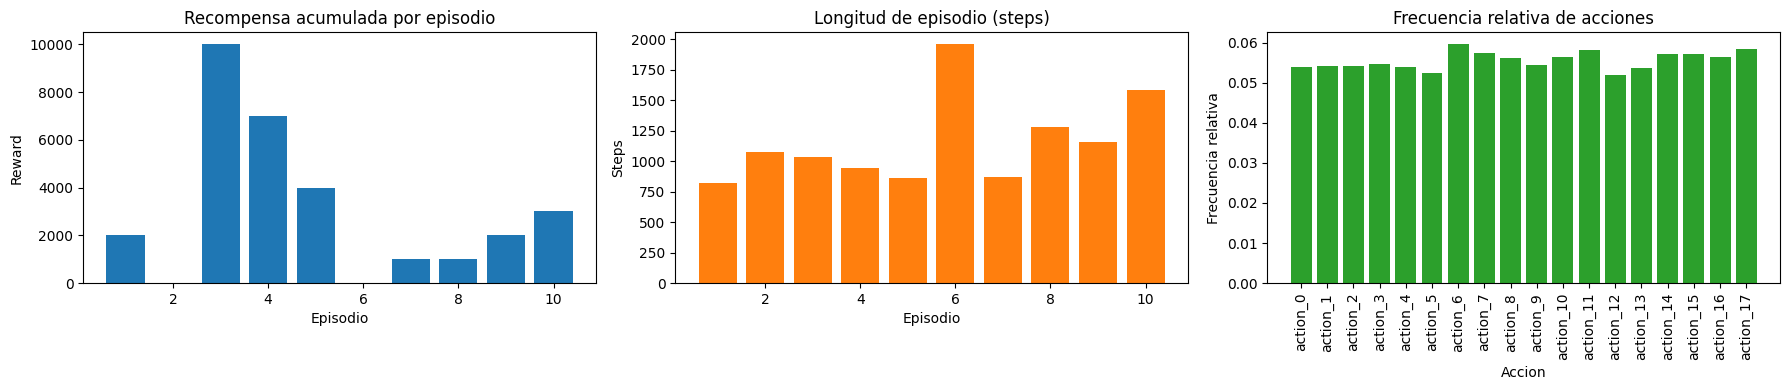

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].bar(episodes_df["episode_id"], episodes_df["reward_total"], color="tab:blue")
axes[0].set_title("Recompensa acumulada por episodio")
axes[0].set_xlabel("Episodio")
axes[0].set_ylabel("Reward")

axes[1].bar(episodes_df["episode_id"], episodes_df["steps"], color="tab:orange")
axes[1].set_title("Longitud de episodio (steps)")
axes[1].set_xlabel("Episodio")
axes[1].set_ylabel("Steps")

axes[2].bar(action_df["action"], action_df["relative"], color="tab:green")
axes[2].set_title("Frecuencia relativa de acciones")
axes[2].set_xlabel("Accion")
axes[2].set_ylabel("Frecuencia relativa")
axes[2].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

In [15]:
# Autovalidaciones automatizables dentro del notebook (AV01-AV13; AV14 diferida).
validation_report = {
    "AV01_imports": "PASS",
    "AV02_env_creation": "PASS",
    "AV03_action_space": "PASS" if inspection["num_actions"] == 18 else "FAIL",
    "AV04_observation": "PASS" if inspection["obs_shape"] == (210, 160, 3) else "FAIL",
    "AV05_action_sampling_reproducibility": "PASS" if action_sequence_reproducible else "FAIL",
    "AV06_short_interaction": "PASS" if len(short_probe_samples) > 0 else "FAIL",
    "AV07_baseline_10_episodes": "PASS" if len(episodes_df) >= 10 else "FAIL",
    "AV08_statistical_integrity": "PASS" if aggregate_metrics["reward_min"] <= aggregate_metrics["reward_mean"] <= aggregate_metrics["reward_max"] else "FAIL",
    "AV09_reward_density_consistency": "PASS" if (total_pos + total_zero + total_neg == steps_total) else "FAIL",
    "AV10_action_frequency_consistency": "PASS" if (sum(action_abs.values()) == steps_total) else "FAIL",
    "AV11_lives_consistency": "PASS" if episodes_df["lives_start"].notna().all() else "PARTIAL",
    "AV12_visualizations": "PASS",
    "AV13_document_coherence": "MANUAL_CHECK_REQUIRED",
    "AV14_colab_full_run": "DEFERRED",
}

pd.DataFrame([validation_report]).T.rename(columns={0: "status"})

,status
AV01_imports,PASS
AV02_env_creation,PASS
AV03_action_space,PASS
AV04_observation,PASS
AV05_action_sampling_reproducibility,PASS
AV06_short_interaction,PASS
AV07_baseline_10_episodes,PASS
AV08_statistical_integrity,PASS
AV09_reward_density_consistency,PASS
AV10_action_frequency_consistency,PASS


## Conclusiones del Experimento 0

Completar esta seccion con base en la ejecucion realizada en el runtime objetivo, separando explicitamente:

1. Hechos observados en ejecucion (contrato, `info`, rewards, vidas, terminacion).
2. Metricas del baseline aleatorio (recompensa, duracion, densidad de reward, acciones).
3. Informacion aun desconocida o no observable en este protocolo.
4. Implicaciones para HU003 (pipeline/preprocessing) sin fijar decisiones definitivas.
5. Implicaciones para HU004 (seleccion de algoritmo) sin seleccionar formalmente aun.

Hallazgos a discutir tipicamente:
- Si la recompensa es escasa y altamente dispersa.
- Si la mayoria de steps tienen reward 0.
- Si `lives` y `frame_number` aparecen consistentemente en `info`.
- Riesgo de degradar radar/objetos pequenos con grayscale + resize agresivo.